In [8]:
import pandas as pd
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt



In [9]:
import os
import pandas as pd
from itertools import combinations

def load_threshold_data(base_path, filenames, key = 'group'):
    """Reads all CSVs in the provided list."""
    filelist = []
    for f in filenames:
        try:
            df = pd.read_csv(os.path.join(base_path, f), sep='\t') 
            df = df[df.cluster == df[key]]
            filelist.append(df)
        except:
            print(f)
            print('file not available')
    return filelist

def get_top_sets_dict(df, n, selector, score_col, on, target):
    """
    Helper to extract the top N sets from a single DataFrame.
    Pre-processing this once per file is much faster than re-calculating 
    during every pairwise comparison.
    """
    top_regulons = (df[df.set_type == selector]
                    .sort_values(['cluster', score_col], ascending=[True, False])
                    .drop_duplicates(subset=['names']))
    
    top_names = top_regulons.groupby('cluster').head(n)['names']
    subset = df[df.names.isin(top_names)]
    
    return subset.groupby(['cluster', on])[target].apply(set).to_dict()

def compute_pairwise_jaccard(dict_a, dict_b, on='source'):
    """Computes Jaccard scores between two pre-processed dictionaries."""
    common_keys = set(dict_a.keys()) & set(dict_b.keys())
    
    rows = []
    for (cluster, source) in common_keys:
        s1, s2 = dict_a[(cluster, source)], dict_b[(cluster, source)]
        intersection = len(s1 & s2)
        union = len(s1 | s2)
        
        rows.append({
            'cluster': cluster,
            on: source,
            'jaccard_score': intersection / union if union > 0 else 0.0,
            'size_a': len(s1),
            'size_b': len(s2)
        })
    return rows

def get_jaccard_report(base_dir, threshold_dict, top_reguls=[5, 10, 20, 50], key = 'group'):
    all_results = []
    
    for tr in top_reguls:
        for label, filenames in threshold_dict.items():
            # 1. Load all DataFrames for this threshold
            dataframes = load_threshold_data(base_dir, filenames, key = key)
            
            if dataframes== []:
                pass
            # 2. Pre-calculate the 'Top Sets' dict for each file to save time
            # We store them with the filename to track the source in the final report
            processed_dicts = []
            for i, df in enumerate(dataframes):
                d_dict = get_top_sets_dict(df, n=tr, selector='all', 
                                           score_col='scores', on='source', target='target')
                processed_dicts.append((filenames[i], d_dict))
            
            # 3. Generate all unique pairs (nCr)
            # e.g., if you have files A, B, C, this generates (A,B), (A,C), (B,C)
            for (name_a, dict_a), (name_b, dict_b) in combinations(processed_dicts, 2):
                pairwise_rows = compute_pairwise_jaccard(dict_a, dict_b)
                
                if pairwise_rows:
                    result_df = pd.DataFrame(pairwise_rows)
                    result_df['threshold'] = label
                    result_df['top_regulons'] = tr
                    result_df['comparison'] = f"{name_a} vs {name_b}"
                    result_df['file_a'] = name_a
                    result_df['file_b'] = name_b
                    all_results.append(result_df)
        
    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)


def make_plot(final_df):
    fig, ax = plt.subplots(figsize=(3, 2.5))
    sns.boxplot(
        data=final_df, 
        x='threshold', 
        y='jaccard_score', 
        hue='top_regulons', 
        fliersize=1, 
        ax=ax
        )

    sns.move_legend(
        ax, 
        loc="upper left", 
        bbox_to_anchor=(1, 1.02), # Positions legend slightly above the plot
        fontsize=8, 
        frameon=True, 
        ncol=1, 
        title='Sources',
        title_fontsize=8, 
    )

    # 4. Formatting labels
    ax.set_xlabel("Targets", fontsize=12)
    ax.set_ylabel("Jaccard Similarity", fontsize=12)

    # Optional: clean up layout to prevent legend clipping
    plt.tight_layout()


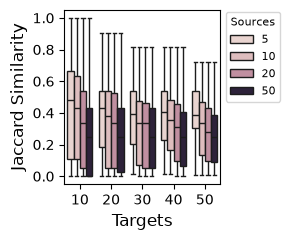

In [10]:
# --- Usage Example ---
basepath = '/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/'

tf = '_source'
s = ''
my_thresholds = {
    "10": [f'bd-rhap-rep1-markers/regulons_10{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_10{tf}{s}.tsv',  f'10x-rep1-kallisto-cellbender-markers/regulons_10{tf}{s}.tsv', f'10x-rep2-kallisto-cellbender-markers/regulons_10{tf}{s}.tsv'],
    "20": [f'bd-rhap-rep1-markers/regulons_20{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_20{tf}{s}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_20{tf}{s}.tsv',f'10x-rep2-kallisto-cellbender-markers/regulons_20{tf}{s}.tsv'],
    "30": [f'bd-rhap-rep1-markers/regulons_30{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_30{tf}{s}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_30{tf}{s}.tsv',f'10x-rep2-kallisto-cellbender-markers/regulons_30{tf}{s}.tsv'],
    "40": [f'bd-rhap-rep1-markers/regulons_40{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_40{tf}{s}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_40{tf}{s}.tsv', f'10x-rep2-kallisto-cellbender-markers/regulons_40{tf}{s}.tsv'],
    "50": [f'bd-rhap-rep1-markers/regulons_50{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_50{tf}{s}.tsv',f'10x-rep1-kallisto-cellbender-markers/regulons_50{tf}{s}.tsv', f'10x-rep2-kallisto-cellbender-markers/regulons_50{tf}{s}.tsv'],
}

# Run the pipeline
final_df = get_jaccard_report(basepath, my_thresholds)
final_df.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/cross_dataset_regulon_stability_source.tsv', sep = '\t')
make_plot(final_df)
plt.savefig('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/cross_dataset_regulon_stability_source.pdf')

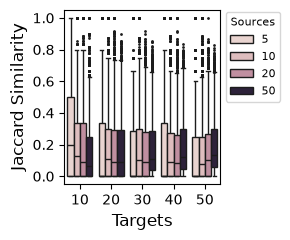

In [11]:
# --- Usage Example ---
basepath = '/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/'

tf = '_target'
s = ''
my_thresholds = {
    "10": [f'bd-rhap-rep1-markers/regulons_10{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_10{tf}{s}.tsv',  f'10x-rep1-kallisto-cellbender-markers/regulons_10{tf}{s}.tsv', f'10x-rep2-kallisto-cellbender-markers/regulons_10{tf}{s}.tsv'],
    "20": [f'bd-rhap-rep1-markers/regulons_20{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_20{tf}{s}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_20{tf}{s}.tsv',f'10x-rep2-kallisto-cellbender-markers/regulons_20{tf}{s}.tsv'],
    "30": [f'bd-rhap-rep1-markers/regulons_30{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_30{tf}{s}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_30{tf}{s}.tsv',f'10x-rep2-kallisto-cellbender-markers/regulons_30{tf}{s}.tsv'],
    "40": [f'bd-rhap-rep1-markers/regulons_40{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_40{tf}{s}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_40{tf}{s}.tsv', f'10x-rep2-kallisto-cellbender-markers/regulons_40{tf}{s}.tsv'],
    "50": [f'bd-rhap-rep1-markers/regulons_50{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_50{tf}{s}.tsv',f'10x-rep1-kallisto-cellbender-markers/regulons_50{tf}{s}.tsv', f'10x-rep2-kallisto-cellbender-markers/regulons_50{tf}{s}.tsv'],
}

# Run the pipeline
final_df = get_jaccard_report(basepath, my_thresholds)
final_df.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/cross_dataset_regulon_stability_target.tsv', sep = '\t')
make_plot(final_df)
plt.savefig('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/cross_dataset_regulon_stability_target.pdf')

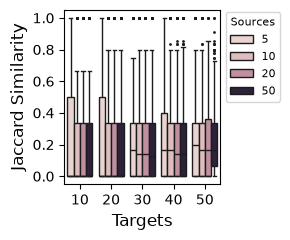

In [12]:
# --- Usage Example ---
basepath = '/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/'

tf = '_target'
s = '_TF'
my_thresholds = {
    "10": [f'bd-rhap-rep1-markers/regulons_10{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_10{tf}{s}.tsv',  f'10x-rep1-kallisto-cellbender-markers/regulons_10{tf}{s}.tsv', f'10x-rep2-kallisto-cellbender-markers/regulons_10{tf}{s}.tsv'],
    "20": [f'bd-rhap-rep1-markers/regulons_20{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_20{tf}{s}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_20{tf}{s}.tsv',f'10x-rep2-kallisto-cellbender-markers/regulons_20{tf}{s}.tsv'],
    "30": [f'bd-rhap-rep1-markers/regulons_30{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_30{tf}{s}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_30{tf}{s}.tsv',f'10x-rep2-kallisto-cellbender-markers/regulons_30{tf}{s}.tsv'],
    "40": [f'bd-rhap-rep1-markers/regulons_40{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_40{tf}{s}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_40{tf}{s}.tsv', f'10x-rep2-kallisto-cellbender-markers/regulons_40{tf}{s}.tsv'],
    "50": [f'bd-rhap-rep1-markers/regulons_50{tf}{s}.tsv', f'bd-rhap-rep2-markers/regulons_50{tf}{s}.tsv',f'10x-rep1-kallisto-cellbender-markers/regulons_50{tf}{s}.tsv', f'10x-rep2-kallisto-cellbender-markers/regulons_50{tf}{s}.tsv'],
}

# Run the pipeline
final_df = get_jaccard_report(basepath, my_thresholds)
final_df.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/cross_dataset_regulon_stability_target_TF.tsv', sep = '\t')
make_plot(final_df)
plt.savefig('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/cross_dataset_regulon_stability_target_TF.pdf')

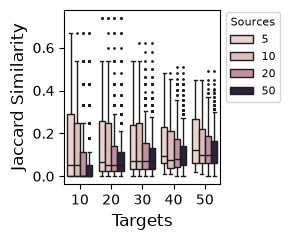

In [13]:
# --- Usage Example ---
basepath = '/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/'
tf = '_TF'
source = '_source'
my_thresholds = {
    "10": [f'bd-rhap-rep1-markers/regulons_10{source}{tf}.tsv', f'bd-rhap-rep2-markers/regulons_10{source}{tf}.tsv',  f'10x-rep1-kallisto-cellbender-markers/regulons_10{source}{tf}.tsv'],
    "20": [f'bd-rhap-rep1-markers/regulons_20{source}{tf}.tsv', f'bd-rhap-rep2-markers/regulons_20{source}{tf}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_20{source}{tf}.tsv'],
    "30": [f'bd-rhap-rep1-markers/regulons_30{source}{tf}.tsv', f'bd-rhap-rep2-markers/regulons_30{source}{tf}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_30{source}{tf}.tsv'],
    "40": [f'bd-rhap-rep1-markers/regulons_40{source}{tf}.tsv', f'bd-rhap-rep2-markers/regulons_40{source}{tf}.tsv', f'10x-rep1-kallisto-cellbender-markers/regulons_40{source}{tf}.tsv'],
    "50": [f'bd-rhap-rep1-markers/regulons_50{source}{tf}.tsv', f'bd-rhap-rep2-markers/regulons_50{source}{tf}.tsv',f'10x-rep1-kallisto-cellbender-markers/regulons_50{source}{tf}.tsv'],
}

# Run the pipeline
final_df = get_jaccard_report(basepath, my_thresholds)
make_plot(final_df)
final_df.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/cross_dataset_regulon_stability_source_TF.tsv', sep = '\t')

plt.savefig('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/cross_dataset_regulon_stability_source_TF.pdf')

10x-rep1-kallisto-cellbender-X-5/regulons_10_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_20_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_30_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_40_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_50_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_10_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_20_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_30_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_40_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_50_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_10_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_20_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_30_TF.tsv
file not available
10x-rep1-kallisto-cellbender-X-5/regulons_40_TF.tsv
file not available
10x-re

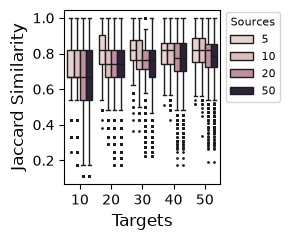

In [14]:
# --- Usage Example ---
basepath = '/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/'

tf = '_TF'
my_thresholds = {
    "10": [f'10x-rep1-kallisto-cellbender-X-{i}/regulons_10{tf}.tsv' for i in range(10)],
    "20": [f'10x-rep1-kallisto-cellbender-X-{i}/regulons_20{tf}.tsv' for i in range(10)],
    "30": [f'10x-rep1-kallisto-cellbender-X-{i}/regulons_30{tf}.tsv' for i in range(10)],
    "40": [f'10x-rep1-kallisto-cellbender-X-{i}/regulons_40{tf}.tsv' for i in range(10)],
    "50": [f'10x-rep1-kallisto-cellbender-X-{i}/regulons_50{tf}.tsv' for i in range(10)],
}

# Run the pipeline
final_df = get_jaccard_report(basepath, my_thresholds, key='celltype')
final_df.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/within_dataset_regulon_stability_10x.tsv', sep = '\t')
make_plot(final_df)
plt.savefig('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/within_dataset_regulon_stability_10x.pdf')